<a href="https://colab.research.google.com/github/kollikrishnarao-star/Rice-disease-Advisory/blob/main/ver2_online_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# -----------------------------
# CONFIG
# -----------------------------
OUTPUT_FILE = "pest_5lag_dataset_fixed_log_ver2.csv"
MIN_ACTIVE = 2


# -----------------------------
# UPLOAD CSV FROM USER
# -----------------------------
print("Upload training dataset CSV")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
df.columns = df.columns.str.strip()


# -----------------------------
# FILTER COLLECTION TYPE
# -----------------------------
VALID_TYPES = ["Number/Light trap", "Percentage"]
df = df[df["Collection Type"].isin(VALID_TYPES)]


# -----------------------------
# GLOBAL SORT
# -----------------------------
df = df.sort_values([
    "PEST NAME",
    "Location",
    "Observation Year",
    "Standard Week"
])


# -----------------------------
# BUILD 5-LAG DATASET
# -----------------------------
rows = []

group_cols = ["PEST NAME", "Location"]

for (pest, loc), g in df.groupby(group_cols):

    g = g.reset_index(drop=True)

    pest_vals = g["Pest Value"].values

    # Need at least 6 weeks
    if len(g) < 6:
        continue

    for i in range(5, len(g) - 1):

        p_now  = max(pest_vals[i], 0)
        p_next = max(pest_vals[i+1], 0)

        p_lag1 = max(pest_vals[i-1], 0)
        p_lag2 = max(pest_vals[i-2], 0)
        p_lag3 = max(pest_vals[i-3], 0)
        p_lag4 = max(pest_vals[i-4], 0)
        p_lag5 = max(pest_vals[i-5], 0)

        # Skip inactive window
        if (
            p_now  < MIN_ACTIVE and
            p_next < MIN_ACTIVE and
            p_lag1 < MIN_ACTIVE and
            p_lag2 < MIN_ACTIVE and
            p_lag3 < MIN_ACTIVE and
            p_lag4 < MIN_ACTIVE and
            p_lag5 < MIN_ACTIVE
        ):
            continue

        row = {
            "pest": pest,
            "location": loc,
            "year": g.loc[i, "Observation Year"],
            "week": g.loc[i, "Standard Week"],

            # Lags
            "pest_t": p_now,
            "pest_lag1": p_lag1,
            "pest_lag2": p_lag2,
            "pest_lag3": p_lag3,
            "pest_lag4": p_lag4,
            "pest_lag5": p_lag5,

            # Climate
            "MaxT": g.loc[i, "MaxT"],
            "MinT": g.loc[i, "MinT"],
            "RH1": g.loc[i, "RH1(%)"],
            "RH2": g.loc[i, "RH2(%)"],
            "RF": g.loc[i, "RF(mm)"],
            "WS": g.loc[i, "WS(kmph)"],
            "SSH": g.loc[i, "SSH(hrs)"],
            "EVP": g.loc[i, "EVP(mm)"],

            # Target
            "pest_next": p_next,
            "delta_pest": p_next - p_now
        }

        rows.append(row)


# -----------------------------
# FINALIZE
# -----------------------------
final_df = pd.DataFrame(rows)

PEST_COLS = [
    "pest_t",
    "pest_lag1",
    "pest_lag2",
    "pest_lag3",
    "pest_lag4",
    "pest_lag5",
    "pest_next"
]

NO_LOG_PESTS = ["LeafBlast", "NeckBlast"]


def conditional_log(pest, value):

    if pest in NO_LOG_PESTS:
        return value

    return np.log1p(value)


for col in PEST_COLS:

    final_df[col] = final_df.apply(
        lambda r: conditional_log(r["pest"], r[col]),
        axis=1
    )


# -----------------------------
# SAVE
# -----------------------------
final_df.to_csv(OUTPUT_FILE, index=False)


# -----------------------------
# DOWNLOAD RESULT
# -----------------------------
files.download(OUTPUT_FILE)


# -----------------------------
# REPORT
# -----------------------------
print("Fixed 5-lag dataset created")
print("Rows:", len(final_df))
print("Saved to:", OUTPUT_FILE)

print("\nCheck pest scales:")
print(final_df[PEST_COLS].describe())

Upload training dataset CSV


Saving rice_original1.csv to rice_original1.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Fixed 5-lag dataset created
Rows: 12981
Saved to: pest_5lag_dataset_fixed_log_ver2.csv

Check pest scales:
             pest_t     pest_lag1     pest_lag2     pest_lag3     pest_lag4  \
count  12981.000000  12981.000000  12981.000000  12981.000000  12981.000000   
mean       4.274709      4.274679      4.269480      4.261394      4.251100   
std        5.249499      5.248671      5.230656      5.205971      5.174166   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        1.098612      1.098612      1.098612      1.098612      1.098612   
50%        3.637586      3.637586      3.637586      3.637586      3.610918   
75%        6.054439      6.049733      6.045005      6.042633      6.030685   
max       87.200000     87.200000     87.200000     87.200000     87.200000   

          pest_lag5     pest_next  
count  12981.000000  12981.000000  
mean       4.238416      4.270224  
std        5.134445      5.252428  
min        0.000000      0.000000  
2

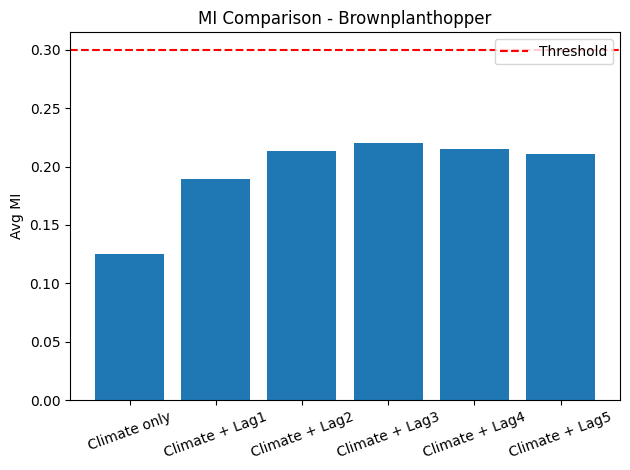

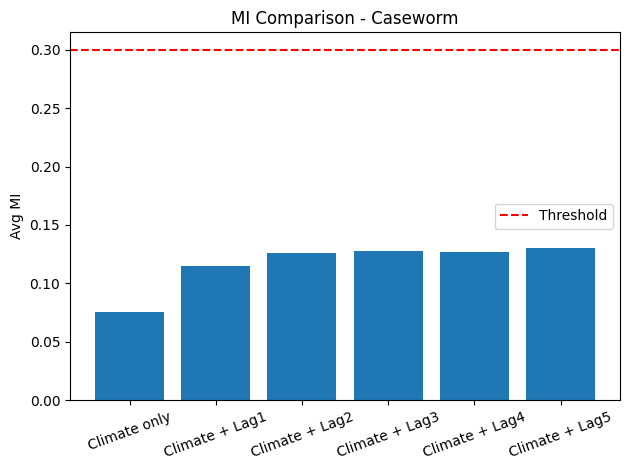

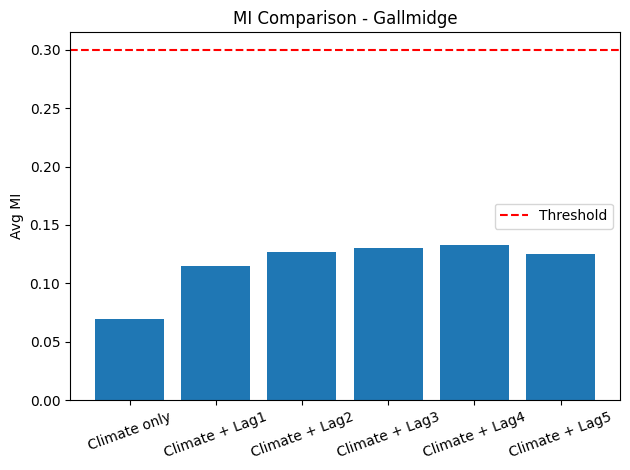

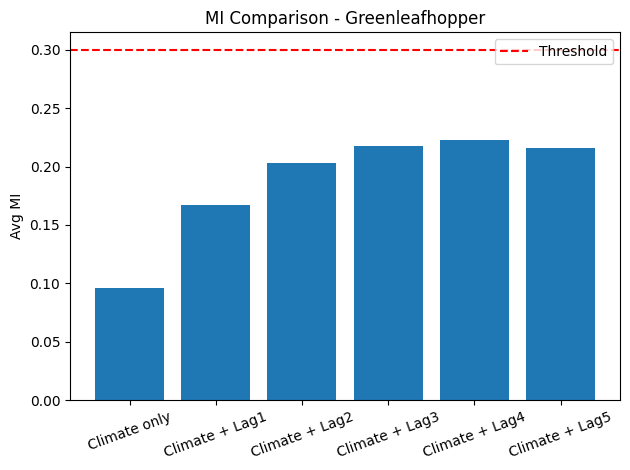

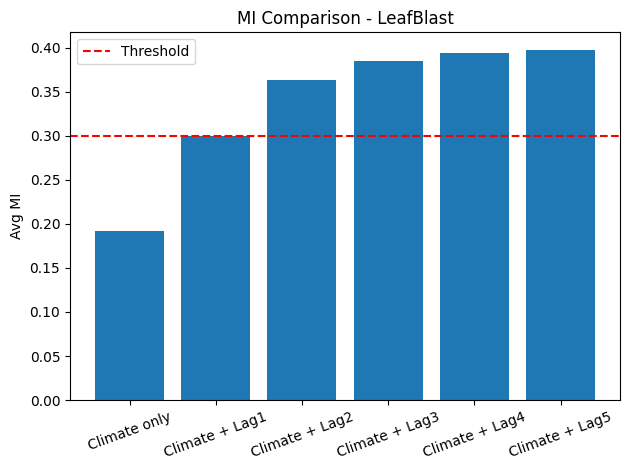

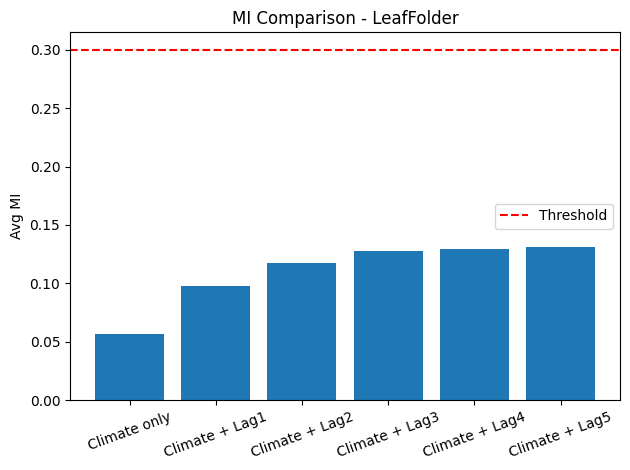

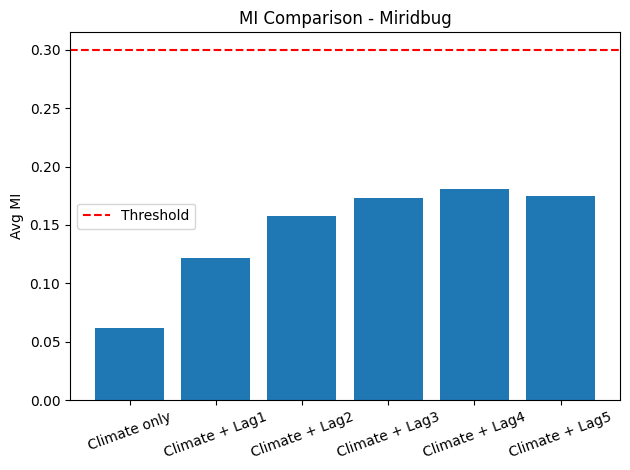

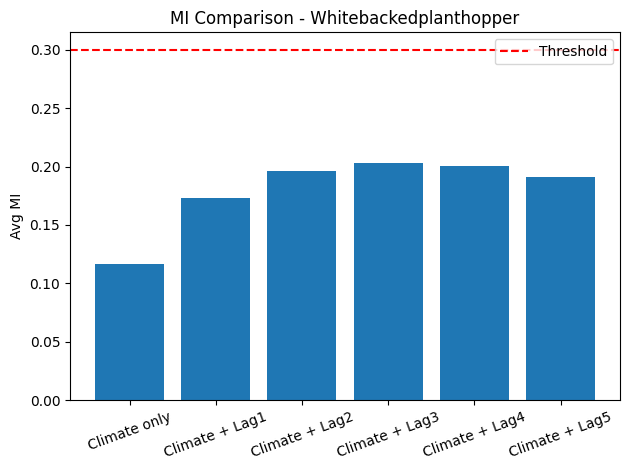

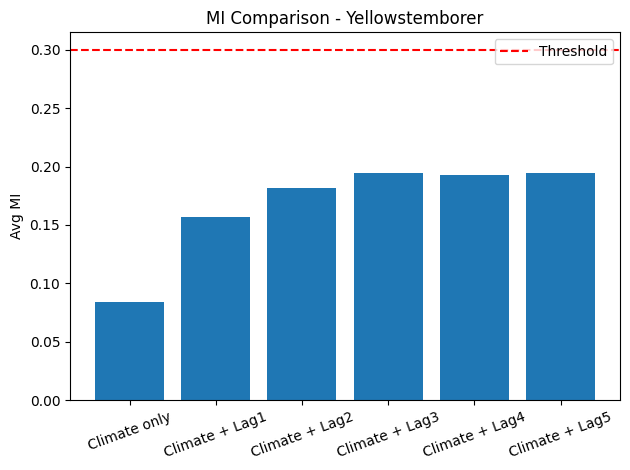

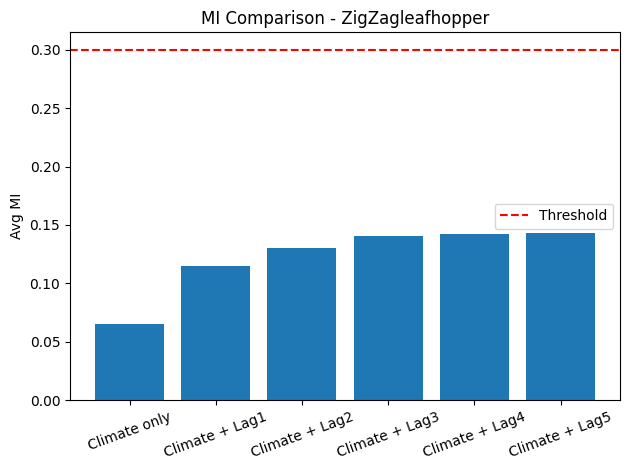


Full MI Table:
                     pest  Climate_only      Lag1      Lag2      Lag3  \
0        Brownplanthopper      0.125438  0.189608  0.212982  0.220352   
1                Caseworm      0.075253  0.114614  0.125804  0.127585   
2               Gallmidge      0.069284  0.115177  0.126556  0.130163   
3         Greenleafhopper      0.095768  0.166787  0.203389  0.218056   
4               LeafBlast      0.191364  0.299200  0.363661  0.384588   
5              LeafFolder      0.056381  0.098085  0.117426  0.127476   
6                Miridbug      0.061561  0.121696  0.158128  0.173502   
7  Whitebackedplanthopper      0.116814  0.173200  0.196502  0.203129   
8         Yellowstemborer      0.083903  0.157210  0.182068  0.194262   
9        ZigZagleafhopper      0.065513  0.115149  0.130197  0.140570   

       Lag4      Lag5   Best_MI  Agent_Selected        Training_Status  
0  0.214731  0.210696  0.220352  Climate + Lag3               Rejected  
1  0.126871  0.130670  0.130670  C

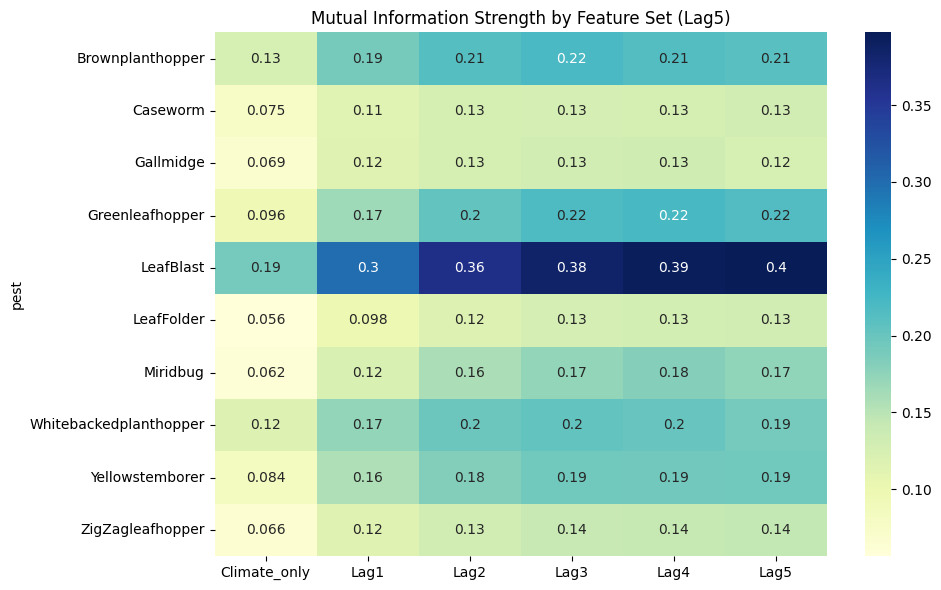

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIG
# -----------------------------
MI_THRESHOLD = 0.3

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("pest_5lag_dataset_fixed_log_ver2.csv")

climate_vars = ['MaxT','MinT','RH1','RH2','RF','WS','SSH','EVP','week']


# -----------------------------
# MI FUNCTION
# -----------------------------
def compute_avg_mi(X, y):

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)

    y = y.loc[X.index]

    mi = mutual_info_regression(X, y, random_state=42)

    return np.mean(mi)


# -----------------------------
# FEATURE SETS
# -----------------------------
def build_feature_sets(df):

    return {
        "Climate only": df[climate_vars],
        "Climate + Lag1": df[climate_vars + ['pest_t']],
        "Climate + Lag2": df[climate_vars + ['pest_t','pest_lag1']],
        "Climate + Lag3": df[climate_vars + ['pest_t','pest_lag1','pest_lag2']],
        "Climate + Lag4": df[climate_vars + ['pest_t','pest_lag1','pest_lag2','pest_lag3']],
        "Climate + Lag5": df[climate_vars + ['pest_t','pest_lag1','pest_lag2','pest_lag3','pest_lag4']]
    }


# -----------------------------
# RUN MI AGENT
# -----------------------------
all_results = []

selected_pests = []
rejected_pests = []

for pest in df['pest'].unique():

    df_p = df[df['pest'] == pest]

    if len(df_p) < 100:
        continue

    y = df_p['pest_next']
    feature_sets = build_feature_sets(df_p)

    results = {}

    for name, X in feature_sets.items():
        score = compute_avg_mi(X, y)
        results[name] = score

    best = max(results, key=results.get)
    max_mi = results[best]

    # -----------------------------
    # SELECTION LOGIC
    # -----------------------------
    if max_mi >= MI_THRESHOLD:
        status = "Selected for Training"
        selected_pests.append(pest)
    else:
        status = "Rejected"
        rejected_pests.append(pest)

    all_results.append({
        "pest": pest,
        "Climate_only": results["Climate only"],
        "Lag1": results["Climate + Lag1"],
        "Lag2": results["Climate + Lag2"],
        "Lag3": results["Climate + Lag3"],
        "Lag4": results["Climate + Lag4"],
        "Lag5": results["Climate + Lag5"],
        "Best_MI": max_mi,
        "Agent_Selected": best,
        "Training_Status": status
    })

    # ---- Plot ----
    plt.figure()
    plt.bar(results.keys(), results.values())
    plt.axhline(MI_THRESHOLD, color='red', linestyle='--', label='Threshold')
    plt.title(f"MI Comparison - {pest}")
    plt.ylabel("Avg MI")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{pest}_MI_plot_5lag.png")
    plt.show()


# -----------------------------
# SUMMARY TABLE
# -----------------------------
mi_table = pd.DataFrame(all_results)
mi_table = mi_table.sort_values("pest")

print("\nFull MI Table:")
print(mi_table)

mi_table.to_csv("MI_agent_decisions_5lag_log.csv", index=False)


# -----------------------------
# SHOW SELECTED VS REJECTED
# -----------------------------
print("\n============================")
print("Pests Selected For Training")
print("============================")

for p in selected_pests:
    print(p)

print("\n============================")
print("Pests Rejected")
print("============================")

for p in rejected_pests:
    print(p)


# Save lists
pd.DataFrame({"Selected_Pests": selected_pests}).to_csv("selected_pests.csv", index=False)
pd.DataFrame({"Rejected_Pests": rejected_pests}).to_csv("rejected_pests.csv", index=False)


# -----------------------------
# HEATMAP
# -----------------------------
plt.figure(figsize=(10,6))

sns.heatmap(
    mi_table.set_index("pest")[["Climate_only","Lag1","Lag2","Lag3","Lag4","Lag5"]],
    annot=True,
    cmap="YlGnBu"
)

plt.title("Mutual Information Strength by Feature Set (Lag5)")
plt.tight_layout()
plt.savefig("MI_heatmap_5lag.png")
plt.show()

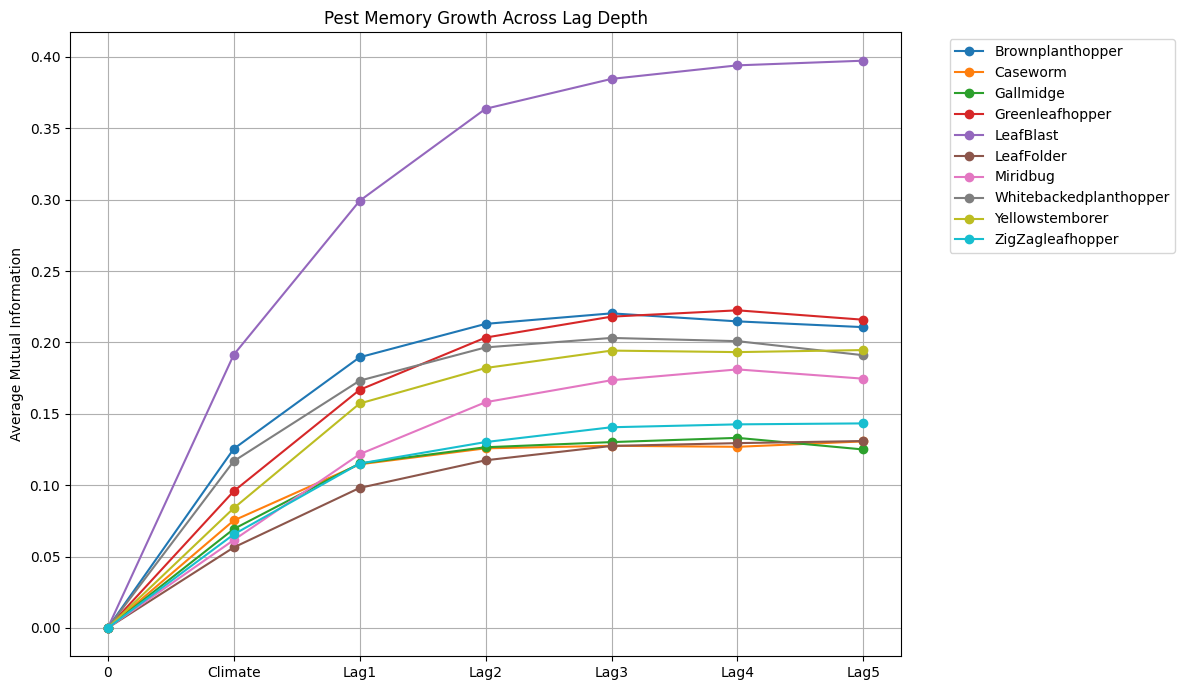

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

mi = pd.read_csv("MI_agent_decisions_5lag_log.csv")
plt.figure(figsize=(12,7))

lags = ['Climate_only','Lag1','Lag2','Lag3','Lag4','Lag5']

for _, row in mi.iterrows():

    values = [0] + [row[l] for l in lags]   # start from 0
    x = list(range(len(values)))

    plt.plot(x, values, marker='o', label=row['pest'])

plt.xticks(
    ticks=range(7),
    labels=['0','Climate','Lag1','Lag2','Lag3','Lag4','Lag5']
)

plt.ylabel("Average Mutual Information")
plt.title("Pest Memory Growth Across Lag Depth")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.savefig("MI_Lag_Curves_AllPests.png")
plt.show()


In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder


# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_csv("pest_5lag_dataset_fixed_log.csv")

df["MaxT"] = df["MaxT"].clip(15, 45)
df["MinT"] = df["MinT"].clip(5, 30)

df["RH1"] = df["RH1"].clip(20, 100)
df["RH2"] = df["RH2"].clip(10, 100)

df["RF"] = df["RF"].clip(0, 350)


df["SSH"] = df["SSH"].clip(0, 84)

# Drop very rare pest
#df = df[df["pest"] != "NeckBlast"]


# -----------------------------
# FEATURES & TARGET
# -----------------------------
climate = ['MaxT','MinT','RH1','RH2','RF','WS','SSH','EVP','week']


def run_model(X, y, pest, mode):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=10
    )

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=10,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    NO_LOG = ["LeafBlast", "NeckBlast"]

    if pest in NO_LOG:
        y_test_real = y_test
        preds_real = preds
    else:
        y_test_real = np.expm1(y_test)
        preds_real = np.expm1(preds)

    preds_real = np.clip(preds_real, 0, None)



    rmse_real = np.sqrt(mean_squared_error(y_test_real, preds_real))
    r2_real = r2_score(y_test_real, preds_real)

    # -----------------------------
    # SAVE TEST PREDICTIONS
    # -----------------------------
    out = X_test.copy()
    out["y_test"] = y_test_real
    out["preds"] = preds_real

    out.to_csv(f"test_preds_{pest}_{mode}.csv", index=False)

    return rmse_real, r2_real




# -----------------------------
# ENCODE LOCATION
# -----------------------------

le_loc = LabelEncoder()
df["location_enc"] = le_loc.fit_transform(df["location"])


def get_features(df, mode):

    if mode == "climate":
        return df[climate]

    if mode == "lag1":
        return df[climate + ['pest_t']]

    if mode == "lag2":
        return df[climate + ['pest_t','pest_lag1']]

    if mode == "lag3":
        return df[climate + ['pest_t','pest_lag1','pest_lag2']]

    if mode == "lag4":
        return df[climate + ['pest_t','pest_lag1','pest_lag2','pest_lag3']]

    if mode == "lag5":
        return df[climate + ['pest_t','pest_lag1','pest_lag2','pest_lag3','pest_lag4']]


results = []

for pest in df['pest'].unique():

    d = df[df['pest']==pest]
    d = d.sort_values(['year','week'])

    if len(d) < 100:
        continue

    y = d['pest_next']

    r = {"pest": pest}

    for mode in ['climate','lag1','lag2','lag3','lag4','lag5']:

        X = get_features(d, mode)

        rmse, r2 = run_model(X, y, pest, mode)

        r[f"RMSE_{mode}"] = rmse
        r[f"R2_{mode}"] = r2


    results.append(r)

perf_table = pd.DataFrame(results)

perf_table.to_csv("Lag_Performance_Comparison_5lag_log_real.csv", index=False)






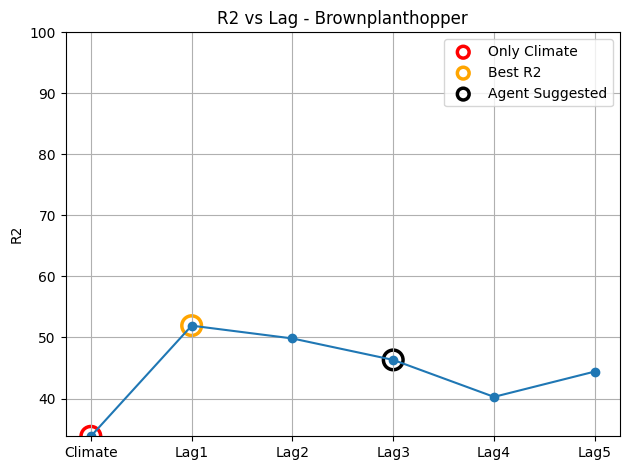

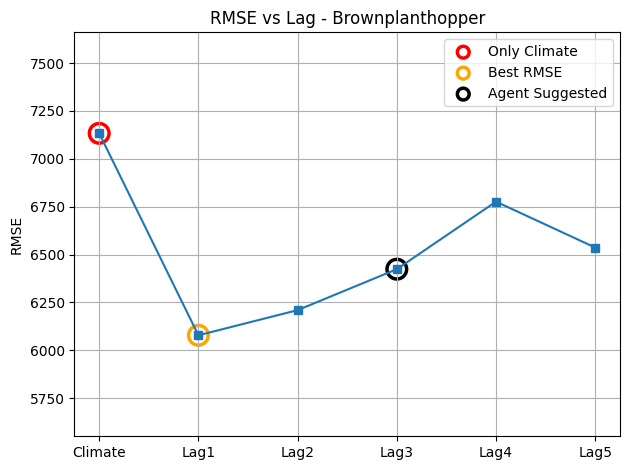

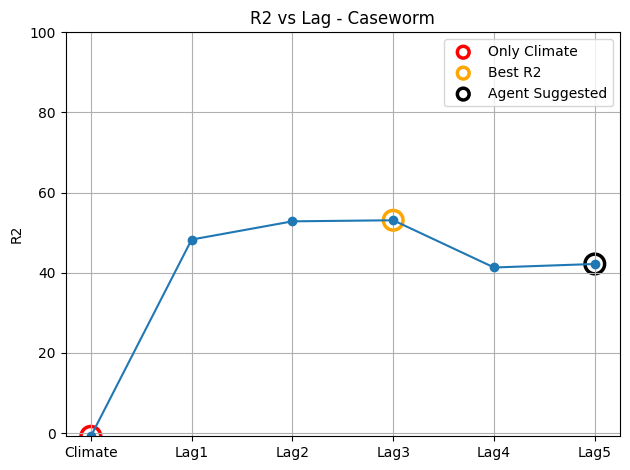

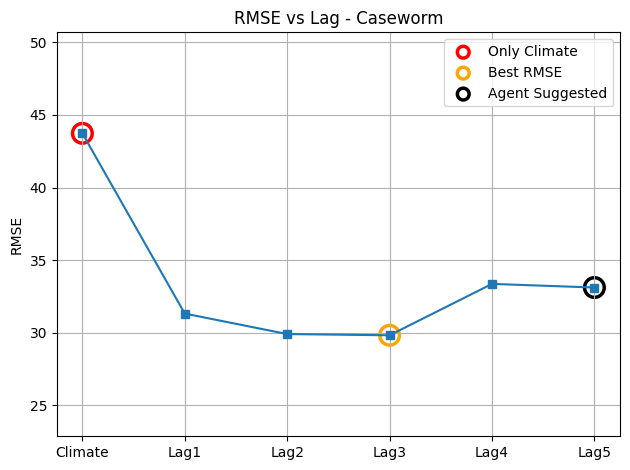

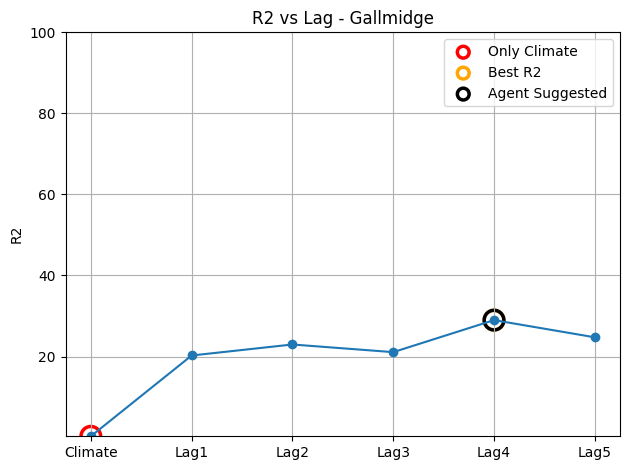

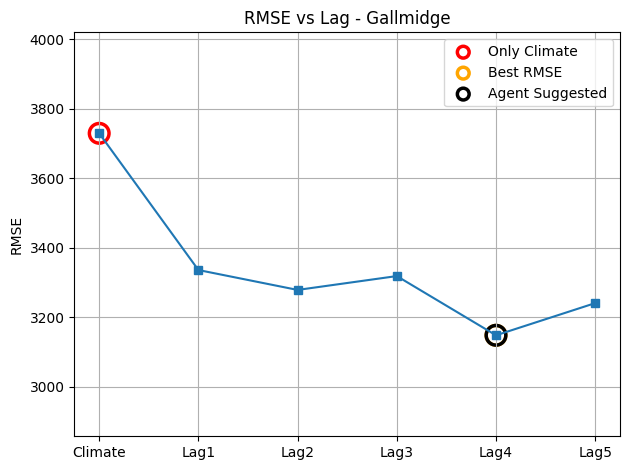

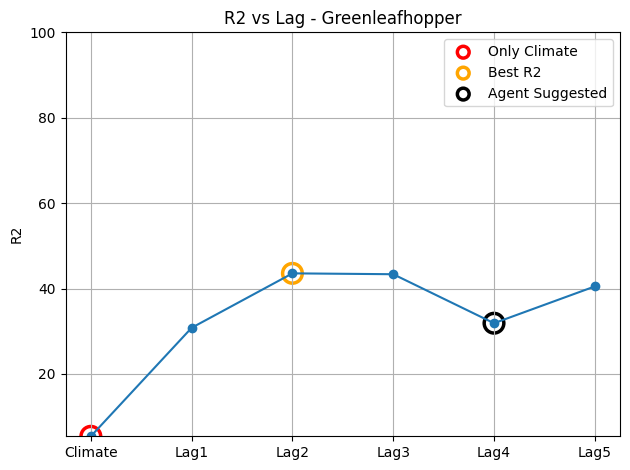

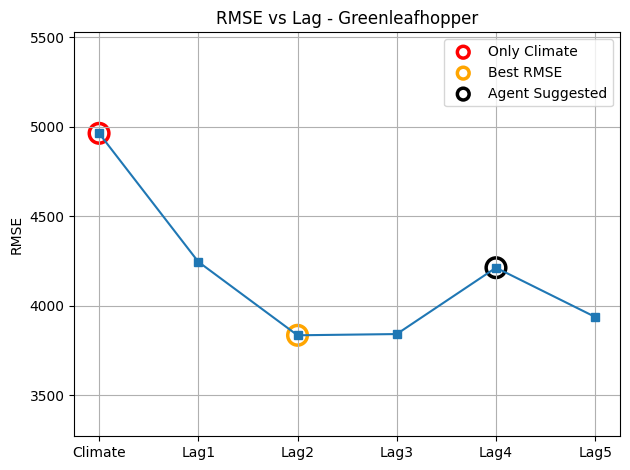

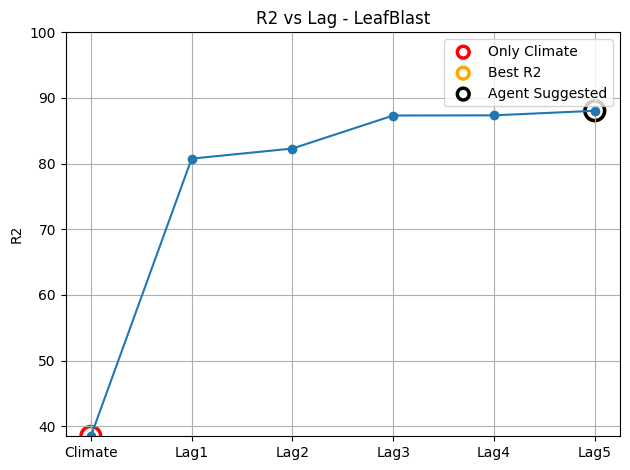

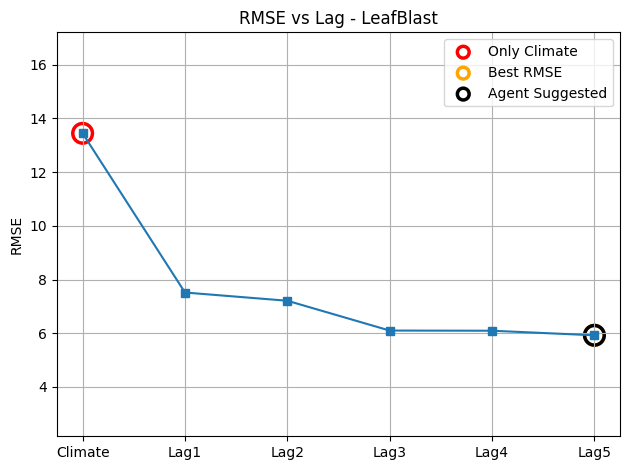

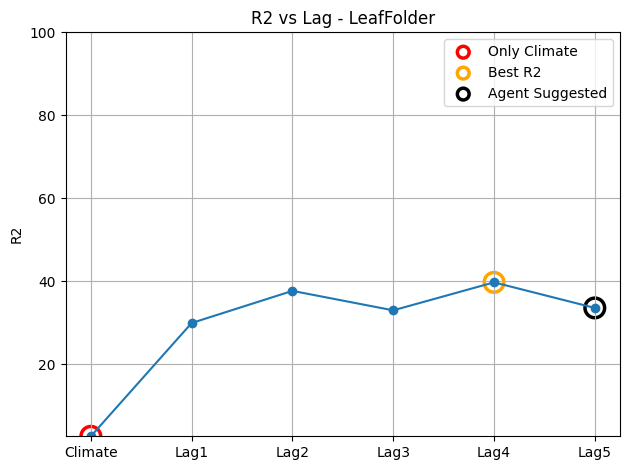

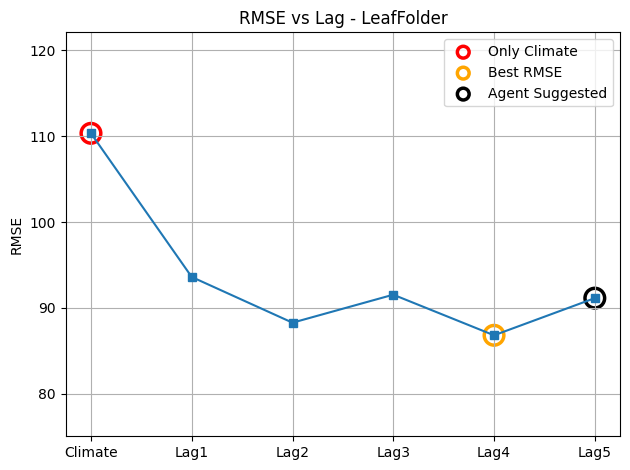

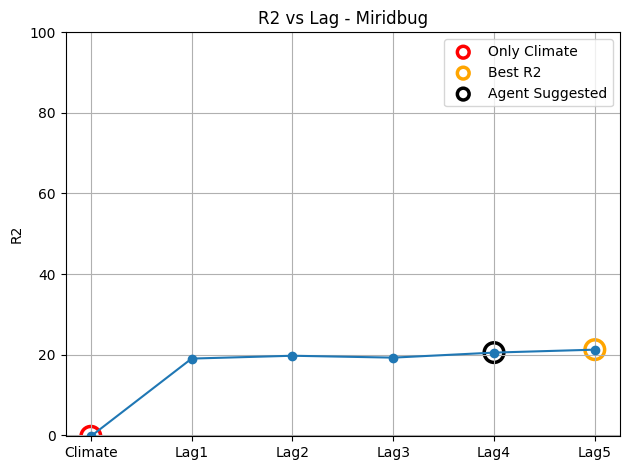

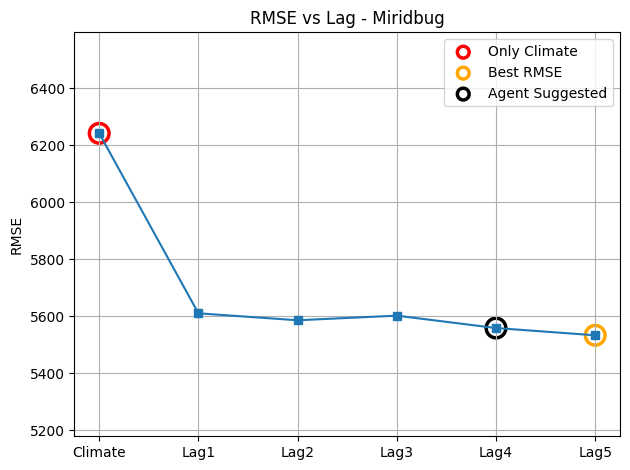

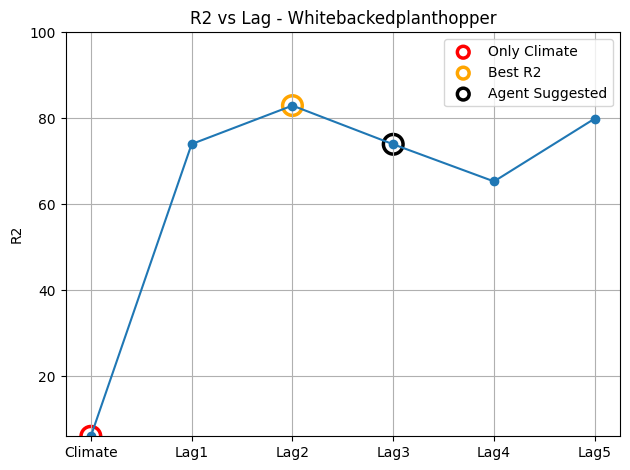

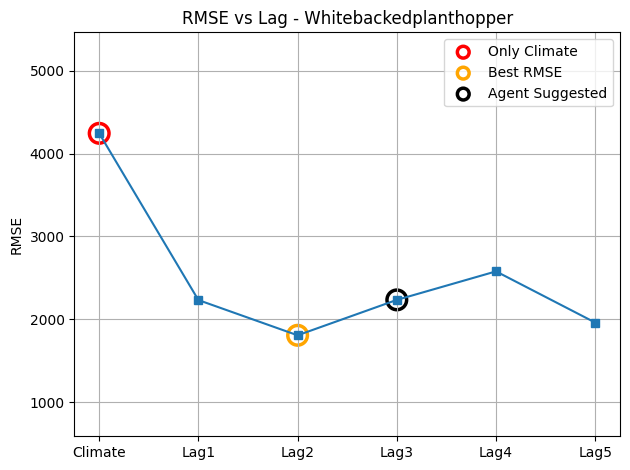

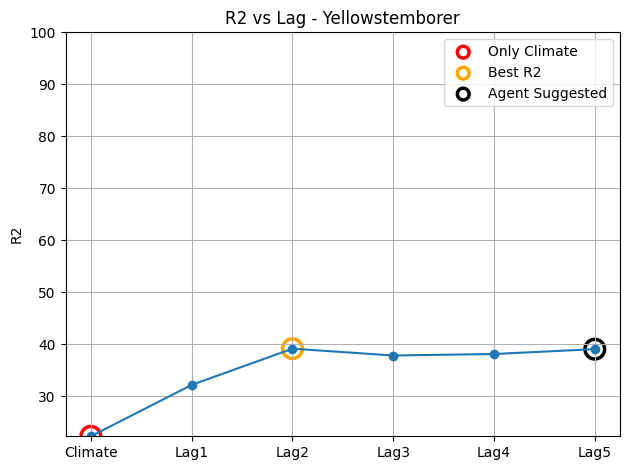

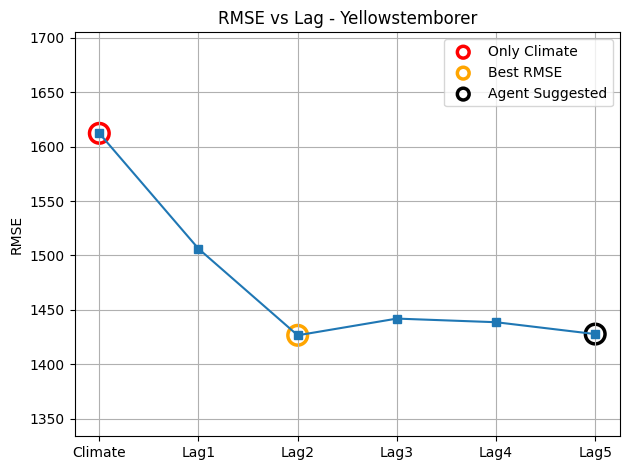

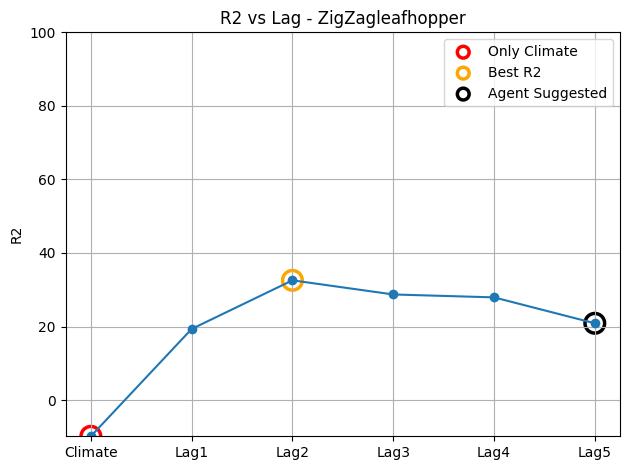

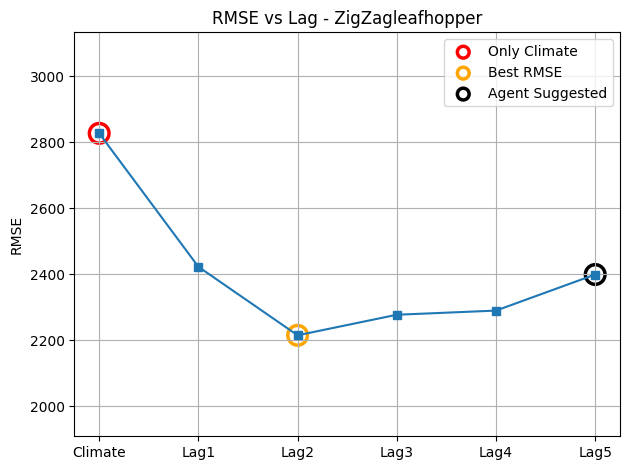

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

perf = pd.read_csv("Lag_Performance_Comparison_5lag_log_real.csv")
mi = pd.read_csv("MI_agent_decisions_5lag_log.csv")

lag_map = {
    "Climate only":0,
    "Climate + Lag1":1,
    "Climate + Lag2":2,
    "Climate + Lag3":3,
    "Climate + Lag4":4,
    "Climate + Lag5":5
}

labels = ['Climate','Lag1','Lag2','Lag3','Lag4','Lag5']
x = list(range(6))

for pest in perf['pest']:

    p_perf = perf[perf['pest']==pest].iloc[0]
    p_mi = mi[mi['pest']==pest].iloc[0]

    r2_vals = [
        p_perf['R2_climate'],
        p_perf['R2_lag1'],
        p_perf['R2_lag2'],
        p_perf['R2_lag3'],
        p_perf['R2_lag4'],
        p_perf['R2_lag5']
    ]

    rmse_vals = [
        p_perf['RMSE_climate'],
        p_perf['RMSE_lag1'],
        p_perf['RMSE_lag2'],
        p_perf['RMSE_lag3'],
        p_perf['RMSE_lag4'],
        p_perf['RMSE_lag5']
    ]

    mi_choice = p_mi['Agent_Selected']
    mi_idx = lag_map[mi_choice]

    climate_idx = 0
    best_r2_idx = r2_vals.index(max(r2_vals))
    best_rmse_idx = rmse_vals.index(min(rmse_vals))

    # ------------------- R2 Plot -------------------
    plt.figure()
    plt.plot(x, r2_vals, marker='o')

    # Climate baseline (RED hollow)
    plt.scatter(climate_idx, r2_vals[climate_idx],
                s=200, facecolors='none', edgecolors='red', linewidths=2.5,label="Only Climate")

    # Best model (GREEN hollow)
    plt.scatter(best_r2_idx, r2_vals[best_r2_idx],
                s=200, facecolors='none', edgecolors='orange', linewidths=2.5,label="Best R2")

    # MI selected (BLUE hollow)
    plt.scatter(mi_idx, r2_vals[mi_idx],
                s=200, facecolors='none', edgecolors='black', linewidths=2.5,label="Agent Suggested")

    plt.xticks(x, labels)
    plt.title(f"R2 vs Lag - {pest}")
    min_r2 = min(r2_vals)
    plt.ylim(min_r2, 1)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}"))
    plt.ylabel("R2")
    plt.legend(markerscale=0.6)
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{pest}_R2_MI.png")
    plt.show()

    # ------------------- RMSE Plot -------------------
    plt.figure()
    plt.plot(x, rmse_vals, marker='s')

    plt.scatter(climate_idx, rmse_vals[climate_idx],
                s=200, facecolors='none', edgecolors='red', linewidths=2.5, label="Only Climate")

    plt.scatter(best_rmse_idx, rmse_vals[best_rmse_idx],
                s=200, facecolors='none', edgecolors='orange', linewidths=2.5, label="Best RMSE")

    plt.scatter(mi_idx, rmse_vals[mi_idx],
                s=200, facecolors='none', edgecolors='black', linewidths=2.5, label="Agent Suggested")

    plt.xticks(x, labels)
    plt.title(f"RMSE vs Lag - {pest}")

    min_rmse = min(rmse_vals)
    max_rmse = max(rmse_vals)

    span = max_rmse - min_rmse
    plt.ylim(min_rmse - 0.5*span, max_rmse + 0.5*span)

    plt.ylabel("RMSE")
    plt.legend(markerscale=0.6)
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{pest}_RMSE_MI.png")
    plt.show()



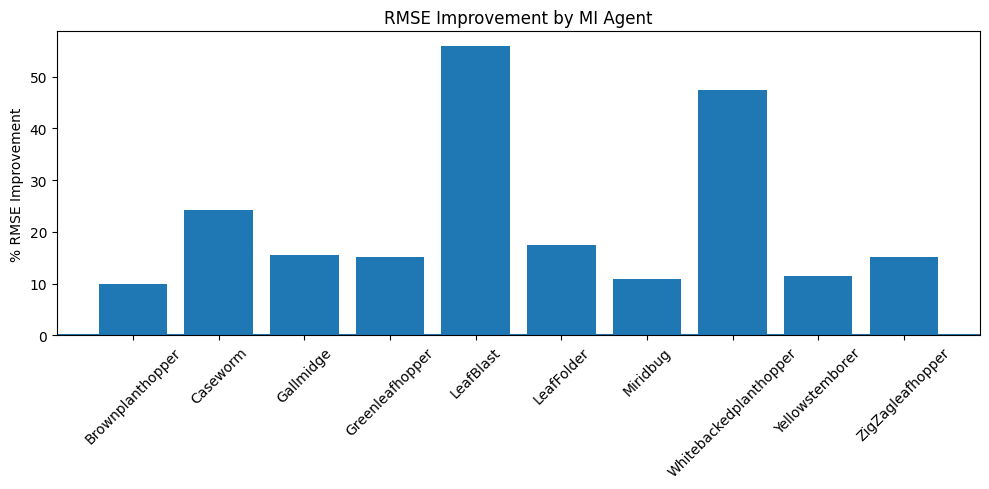

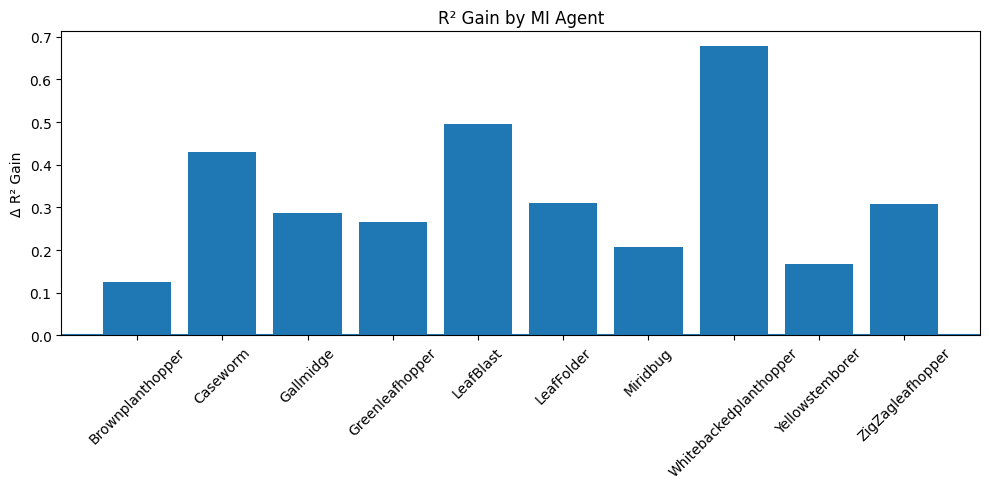

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

perf = pd.read_csv("Lag_Performance_Comparison_5lag_log_real.csv")
mi = pd.read_csv("MI_agent_decisions_5lag_log.csv")

rmse_map = {
    "Climate only":"RMSE_climate",
    "Climate + Lag1":"RMSE_lag1",
    "Climate + Lag2":"RMSE_lag2",
    "Climate + Lag3":"RMSE_lag3",
    "Climate + Lag4":"RMSE_lag4",
    "Climate + Lag5":"RMSE_lag5"
}

r2_map = {
    "Climate only":"R2_climate",
    "Climate + Lag1":"R2_lag1",
    "Climate + Lag2":"R2_lag2",
    "Climate + Lag3":"R2_lag3",
    "Climate + Lag4":"R2_lag4",
    "Climate + Lag5":"R2_lag5"
}

results = []

for pest in perf['pest']:

    p_perf = perf[perf['pest']==pest].iloc[0]
    p_mi = mi[mi['pest']==pest].iloc[0]

    mi_lag = p_mi['Agent_Selected']

    # RMSE Improvement (%)
    climate_rmse = p_perf['RMSE_climate']
    mi_rmse = p_perf[rmse_map[mi_lag]]
    rmse_imp = ((climate_rmse - mi_rmse) / climate_rmse) * 100

    # R2 Gain (Absolute)
    climate_r2 = p_perf['R2_climate']
    mi_r2 = p_perf[r2_map[mi_lag]]
    r2_gain = mi_r2 - climate_r2

    results.append({
        "pest": pest,
        "RMSE_Improvement_%": rmse_imp,
        "R2_Gain": r2_gain
    })

imp_df = pd.DataFrame(results)


plt.figure(figsize=(10,5))

plt.bar(imp_df['pest'], imp_df['RMSE_Improvement_%'])

plt.axhline(0)
plt.xticks(rotation=45)
plt.ylabel("% RMSE Improvement")
plt.title("RMSE Improvement by MI Agent over pure climate model")

plt.tight_layout()
plt.savefig("RMSE_Improvement.png")
plt.show()

plt.figure(figsize=(10,5))

plt.bar(imp_df['pest'], imp_df['R2_Gain'])

plt.axhline(0)
plt.xticks(rotation=45)
plt.ylabel("Δ R² Gain")
plt.title("R² Gain by MI Agent")

plt.tight_layout()
plt.savefig("R2_Gain.png")
plt.show()


In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder


# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_csv("pest_5lag_dataset_fixed_log.csv")

df["MaxT"] = df["MaxT"].clip(15, 45)
df["MinT"] = df["MinT"].clip(5, 30)

df["RH1"] = df["RH1"].clip(20, 100)
df["RH2"] = df["RH2"].clip(10, 100)

df["RF"] = df["RF"].clip(0, 350)


df["SSH"] = df["SSH"].clip(0, 84)

# Drop very rare pest
#df = df[df["pest"] != "NeckBlast"]


# -----------------------------
# FEATURES & TARGET
# -----------------------------
climate = ['MaxT','MinT','RH1','RH2','RF','WS','SSH','EVP', 'week']


model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=10,
    objective="reg:squarederror"
)


def run_model(X, y, pest, mode):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=10
    )



    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    NO_LOG = ["LeafBlast", "NeckBlast"]

    if pest in NO_LOG:
        y_test_real = y_test
        preds_real = preds
    else:
        y_test_real = np.expm1(y_test)
        preds_real = np.expm1(preds)

    preds_real = np.clip(preds_real, 0, None)



    rmse_real = np.sqrt(mean_squared_error(y_test_real, preds_real))
    r2_real = r2_score(y_test_real, preds_real)

    # -----------------------------
    # SAVE TEST PREDICTIONS
    # -----------------------------
    out = X_test.copy()
    out["y_test"] = y_test_real
    out["preds"] = preds_real

    out.to_csv(f"test_preds_{pest}_{mode}.csv", index=False)

    return rmse_real, r2_real




# -----------------------------
# ENCODE LOCATION
# -----------------------------

le_loc = LabelEncoder()
df["location_enc"] = le_loc.fit_transform(df["location"])


def get_features(df, mode):

    if mode == "climate":
        return df[climate]

    if mode == "lag1":
        return df[climate + ['pest_t']]

    if mode == "lag2":
        return df[climate + ['pest_t','pest_lag1']]

    if mode == "lag3":
        return df[climate + ['pest_t','pest_lag1','pest_lag2']]

    if mode == "lag4":
        return df[climate + ['pest_t','pest_lag1','pest_lag2','pest_lag3']]

    if mode == "lag5":
        return df[climate + ['pest_t','pest_lag1','pest_lag2','pest_lag3','pest_lag4']]


results = []

# -----------------------------
# RUN ONLY FOR LEAFBLAST
# -----------------------------

pest = "LeafBlast"

d = df[df['pest'] == pest]
d = d.sort_values(['year','week'])

if len(d) >= 100:

    y = d['pest_next']

    r = {"pest": pest}

    for mode in ['lag5']:

        X = get_features(d, mode)

        rmse, r2 = run_model(X, y, pest, mode)

        r[f"RMSE_{mode}"] = rmse
        r[f"R2_{mode}"] = r2

    results.append(r)

perf_table = pd.DataFrame(results)
perf_table.to_csv("LeafBlast_Climate_vs_Lag5.csv", index=False)















In [ ]:
!pip install geopy


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import requests
import joblib
from datetime import datetime
from geopy.geocoders import Nominatim


geolocator = Nominatim(user_agent="blast_wizard")

# ---------- UI ----------

location = widgets.Text(description="Location")
lat = widgets.FloatText(description="Latitude")
lon = widgets.FloatText(description="Longitude")

lag1 = widgets.FloatText(value=0, description="Lag1")
lag2 = widgets.FloatText(value=0, description="Lag2")
lag3 = widgets.FloatText(value=0, description="Lag3")
lag4 = widgets.FloatText(value=0, description="Lag4")
lag5 = widgets.FloatText(value=0, description="Lag5")

predict_btn = widgets.Button(description="Predict Blast")

display(location, lat, lon, lag1, lag2, lag3, lag4, lag5, predict_btn)

# ---------- Get Lat Long ----------

def autofill_latlon():
    if location.value.strip() != "":
        loc = geolocator.geocode(location.value)
        if loc:
            lat.value = loc.latitude
            lon.value = loc.longitude

# ---------- Fetch Climate ----------

from datetime import timedelta


def fetch_climate(lat, lon):

    today = datetime.today()
    start_day = today - timedelta(days=10)
    end_day = today - timedelta(days=3)

    start = start_day.strftime("%Y%m%d")
    end = end_day.strftime("%Y%m%d")

    url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,EVPTRNS&community=AG&longitude={lon}&latitude={lat}&start={start}&end={end}&format=JSON"

    data = requests.get(url).json()
    p = data["properties"]["parameter"]

    def latest_valid(param):
        vals = list(param.values())
        for v in reversed(vals):
            if v != -999:
                return v
        return None

    return {
        "MaxT": latest_valid(p["T2M_MAX"]),
        "MinT": latest_valid(p["T2M_MIN"]),
        "RH": latest_valid(p["RH2M"]),
        "RF": latest_valid(p["PRECTOTCORR"]),
        "WS": latest_valid(p["WS2M"]),
        "SSH": latest_valid(p["ALLSKY_SFC_SW_DWN"]),
        "EVP": latest_valid(p["EVPTRNS"])
    }




# ---------- RH1 RH2 ----------

def compute_rh(MaxT, MinT, RH):

    Tmean = (MaxT + MinT)/2

    def es(T):
        return 0.6108 * np.exp((17.27 * T)/(T+237.3))

    ea = (RH/100) * es(Tmean)

    RH1 = (ea / es(MinT)) * 100
    RH2 = (ea / es(MaxT)) * 100

    return np.clip(RH1,0,100), np.clip(RH2,0,100)

# ---------- Predict ----------

def on_predict(b):

    clear_output(wait=True)
    display(location, lat, lon, lag1, lag2, lag3, lag4, lag5, predict_btn)

    autofill_latlon()

    climate = fetch_climate(lat.value, lon.value)

    if None in climate.values():
      print(" Climate data unavailable from NASA. Try again later.")
      return

    RH1, RH2 = compute_rh(climate["MaxT"], climate["MinT"], climate["RH"])


    week = datetime.today().isocalendar()[1]

    features = [
        climate["MaxT"],
        climate["MinT"],
        RH1,
        RH2,
        climate["RF"],
        climate["WS"],
        climate["SSH"],
        climate["EVP"],
        week,
        0,
        lag1.value,
        lag2.value,
        lag3.value,
        lag4.value
    ]

    pred = model.predict([features])[0]
    pred = max(pred,0)

    print("\nLocation:", location.value if location.value else f"{lat.value},{lon.value}")

    print("\n Climate details:")
    print("----------------------------------")
    print(f"MaxT  : {round(climate['MaxT'],2)}")
    print(f"MinT  : {round(climate['MinT'],2)}")
    print(f"RH1   : {round(RH1,2)}")
    print(f"RH2   : {round(RH2,2)}")
    print(f"RF    : {round(climate['RF'],2)}")
    print(f"WS    : {round(climate['WS'],2)}")
    print(f"SSH   : {round(climate['SSH'],2)}")
    print(f"EVP   : {round(climate['EVP'],2)}")
    print(f"Week  : {week}")
    print("----------------------------------")

    print("\n🌾 Predicted LeafBlast =", round(pred,2))

predict_btn.on_click(on_predict)


Text(value='Delhi', description='Location')

FloatText(value=28.6138954, description='Latitude')

FloatText(value=77.2090057, description='Longitude')

FloatText(value=3.0, description='Lag1')

FloatText(value=4.0, description='Lag2')

FloatText(value=5.0, description='Lag3')

FloatText(value=6.0, description='Lag4')

FloatText(value=7.0, description='Lag5')

Button(description='Predict Blast', style=ButtonStyle())


Location: Delhi

 Climate details:
----------------------------------
MaxT  : 27.29
MinT  : 12.21
RH1   : 61.33
RH2   : 24.05
RF    : 0.0
WS    : 2.01
SSH   : 16.19
EVP   : 0.64
Week  : 7
----------------------------------

🌾 Predicted LeafBlast = 5.66


Text(value='vijayawada', description='Location')

FloatText(value=0.0, description='Latitude')

FloatText(value=0.0, description='Longitude')

FloatText(value=3.0, description='Lag1')

FloatText(value=1.0, description='Lag2')

...

FloatText(value=3.0, description='Lag4')

FloatText(value=4.0, description='Lag5')

Button(description='Predict Blast', style=ButtonStyle())


Location: vijayawada

 Climate details:
----------------------------------
MaxT  : 33.2
MinT  : 21.0
RH1   : 94.0
RH2   : 35.0
RF    : 0.0
WS    : 3.55
SSH   : 5.85
EVP   : 2.4
Week  : 7
----------------------------------

 Predicted LeafBlast = 5.34

 5-Day Forecast


,Date,MaxT,MinT,RH1,RH2,RF,WS,SSH,EVP,week,Predicted_Blast
0,2026-02-15,33.2,21.0,94.0,35.0,0.0,3.55,5.85,2.40,7,5.34
1,2026-02-16,32.7,21.6,92.0,39.0,0.0,5.64,6.05,2.34,8,5.09
2,2026-02-17,32.2,21.0,92.0,39.0,0.0,6.48,5.82,2.24,8,5.28
3,2026-02-18,33.0,21.3,90.0,38.0,0.0,4.84,6.45,2.58,8,4.76
4,2026-02-19,33.8,19.5,92.0,35.0,0.0,4.56,6.33,2.84,8,4.76
5,2026-02-20,35.1,21.2,82.0,24.0,0.0,6.16,6.42,2.91,8,4.96
6,2026-02-21,34.5,20.9,85.0,33.0,0.0,6.16,6.39,2.83,8,5.01
7,2026-02-22,34.5,20.6,91.0,36.0,0.0,5.58,6.39,2.87,8,4.80


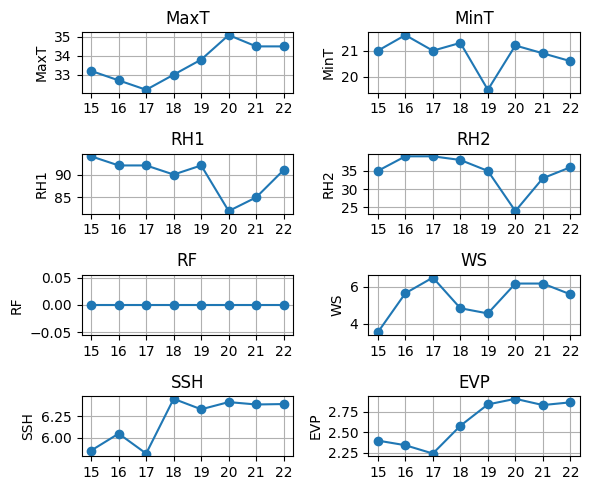

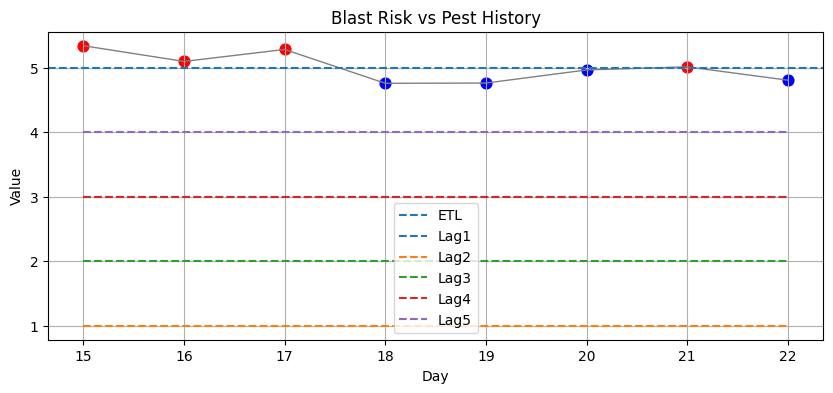

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import requests
import joblib
from datetime import datetime
from geopy.geocoders import Nominatim


geolocator = Nominatim(user_agent="blast_wizard")

# ---------- UI ----------

location = widgets.Text(description="Location")
lat = widgets.FloatText(description="Latitude")
lon = widgets.FloatText(description="Longitude")

lag1 = widgets.FloatText(value=0, description="Lag1")
lag2 = widgets.FloatText(value=0, description="Lag2")
lag3 = widgets.FloatText(value=0, description="Lag3")
lag4 = widgets.FloatText(value=0, description="Lag4")
lag5 = widgets.FloatText(value=0, description="Lag5")

predict_btn = widgets.Button(description="Predict Blast")

display(location, lat, lon, lag1, lag2, lag3, lag4, lag5, predict_btn)

# ---------- Get Lat Long ----------

def autofill_latlon():
    if location.value.strip() != "":
        loc = geolocator.geocode(location.value)
        if loc:
            lat.value = loc.latitude
            lon.value = loc.longitude

# ---------- Fetch Climate ----------

from datetime import timedelta

def fetch_current_openmeteo(lat, lon):

    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=auto"

    data = requests.get(url).json()

    hourly = pd.DataFrame(data["hourly"])
    hourly["time"] = pd.to_datetime(hourly["time"])

    daily = pd.DataFrame(data["daily"])

    today = pd.to_datetime(daily["time"][0]).date()

    day_data = hourly[hourly["time"].dt.date == today]

    MaxT = daily.loc[0,"temperature_2m_max"]
    MinT = daily.loc[0,"temperature_2m_min"]
    RF = daily.loc[0,"precipitation_sum"]

    RH1 = day_data[day_data["time"].dt.hour == 6]["relative_humidity_2m"].mean()
    RH2 = day_data[day_data["time"].dt.hour == 15]["relative_humidity_2m"].mean()

    WS = day_data["wind_speed_10m"].mean()

    SSH = day_data["shortwave_radiation"].sum()/1000

    EVP = (0.0023*(MaxT+17.8)*(MaxT-MinT)**0.5)*SSH

    return {
        "MaxT":MaxT,
        "MinT":MinT,
        "RH1":RH1,
        "RH2":RH2,
        "RF":RF,
        "WS":WS,
        "SSH":SSH,
        "EVP":EVP
    }




def fetch_forecast(lat, lon):

    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&forecast_days=8&timezone=auto"

    data = requests.get(url).json()

    hourly = pd.DataFrame(data["hourly"])
    hourly["time"] = pd.to_datetime(hourly["time"])

    daily = pd.DataFrame(data["daily"])

    forecast = []

    for day in daily["time"]:

        day_data = hourly[hourly["time"].dt.date == pd.to_datetime(day).date()]

        MaxT = daily.loc[daily["time"]==day,"temperature_2m_max"].values[0]
        MinT = daily.loc[daily["time"]==day,"temperature_2m_min"].values[0]
        RF = daily.loc[daily["time"]==day,"precipitation_sum"].values[0]

        RH1 = day_data[day_data["time"].dt.hour == 6]["relative_humidity_2m"].mean()
        RH2 = day_data[day_data["time"].dt.hour == 15]["relative_humidity_2m"].mean()

        WS = day_data["wind_speed_10m"].mean()
        SSH = day_data["shortwave_radiation"].sum()/1000

        EVP = (0.0023*(MaxT+17.8)*(MaxT-MinT)**0.5)*SSH

        forecast.append([day,MaxT,MinT,RH1,RH2,RF,WS,SSH,EVP])

    return pd.DataFrame(forecast, columns=[
        "Date","MaxT","MinT","RH1","RH2","RF","WS","SSH","EVP"
    ])



def fetch_climate(lat, lon):

    today = datetime.today()
    start_day = today - timedelta(days=10)
    end_day = today - timedelta(days=3)

    start = start_day.strftime("%Y%m%d")
    end = end_day.strftime("%Y%m%d")

    url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,EVPTRNS&community=AG&longitude={lon}&latitude={lat}&start={start}&end={end}&format=JSON"

    data = requests.get(url).json()
    p = data["properties"]["parameter"]

    def latest_valid(param):
        vals = list(param.values())
        for v in reversed(vals):
            if v != -999:
                return v
        return None

    rad = latest_valid(p["ALLSKY_SFC_SW_DWN"])


    return {
        "MaxT": latest_valid(p["T2M_MAX"]),
        "MinT": latest_valid(p["T2M_MIN"]),
        "RH": latest_valid(p["RH2M"]),
        "RF": latest_valid(p["PRECTOTCORR"]),
        "WS": latest_valid(p["WS2M"]),
        "SSH": rad/2 if rad else None,
        "EVP": latest_valid(p["EVPTRNS"])
    }



# ---------- RH1 RH2 ----------

def compute_rh(MaxT, MinT, RH):

    Tmean = (MaxT + MinT)/2

    def es(T):
        return 0.6108 * np.exp((17.27 * T)/(T+237.3))

    ea = (RH/100) * es(Tmean)

    RH1 = (ea / es(MinT)) * 100
    RH2 = (ea / es(MaxT)) * 100

    return np.clip(RH1,0,100), np.clip(RH2,0,100)

# ---------- Predict ----------

import matplotlib.pyplot as plt

def on_predict(b):

    clear_output(wait=True)
    display(location, lat, lon, lag1, lag2, lag3, lag4, lag5, predict_btn)

    autofill_latlon()

    # -------- TODAY (NASA) --------
    climate = fetch_current_openmeteo(lat.value, lon.value)

    if None in climate.values():
        print("Climate unavailable")
        return

    RH1 = climate["RH1"]
    RH2 = climate["RH2"]
    week = datetime.today().isocalendar()[1]

    features_today = [
      climate["MaxT"], climate["MinT"], RH1, RH2,
      climate["RF"], climate["WS"], climate["SSH"], climate["EVP"],
      week,
      lag1.value,  # pest_t
      lag2.value,  # lag1
      lag3.value,  # lag2
      lag4.value,  # lag3
      lag5.value   # lag4
      ]


    pred_today = max(model.predict([features_today])[0],0)

    # -------- KEEP OLD OUTPUT --------

    print("\nLocation:", location.value if location.value else f"{lat.value},{lon.value}")

    print("\n Climate details:")
    print("----------------------------------")
    print(f"MaxT  : {round(climate['MaxT'],2)}")
    print(f"MinT  : {round(climate['MinT'],2)}")
    print(f"RH1   : {round(RH1,2)}")
    print(f"RH2   : {round(RH2,2)}")
    print(f"RF    : {round(climate['RF'],2)}")
    print(f"WS    : {round(climate['WS'],2)}")
    print(f"SSH   : {round(climate['SSH'],2)}")
    print(f"EVP   : {round(climate['EVP'],2)}")
    print(f"Week  : {week}")
    print("----------------------------------")

    print("\n Predicted LeafBlast =", round(pred_today,2))

    # -------- NEXT 5 DAYS --------
    forecast = fetch_forecast(lat.value, lon.value)
    forecast["week"] = pd.to_datetime(forecast["Date"]).dt.isocalendar().week

    full = forecast.copy()
    preds = []

    pest_t = lag1.value
    l1 = lag2.value
    l2 = lag3.value
    l3 = lag4.value
    l4 = lag5.value

    for i,row in full.iterrows():

        features = [[
            row.MaxT,row.MinT,row.RH1,row.RH2,row.RF,row.WS,row.SSH,row.EVP,
            int(row.week),
            pest_t,l1,l2,l3,l4
        ]]

        pred = max(model.predict(features)[0],0)
        preds.append(pred)


    full["Predicted_Blast"] = preds

    # -------- TABLE --------
    print("\n 5-Day Forecast")
    display(full.round(2))

    import matplotlib.pyplot as plt

    full["Date"] = pd.to_datetime(full["Date"])
    full["Day"] = full["Date"].dt.strftime("%d")

    climate_vars = ["MaxT","MinT","RH1","RH2","RF","WS","SSH","EVP"]

    fig, axes = plt.subplots(4,2, figsize=(6,5))
    axes = axes.flatten()

    for i,var in enumerate(climate_vars):
        axes[i].plot(full["Day"], full[var], marker='o')
        axes[i].set_title(var)
        axes[i].set_xlabel("")
        axes[i].set_ylabel(var)
        axes[i].grid()

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(10,4))

    days = full["Day"]
    blast = full["Predicted_Blast"]

    # Plot line (neutral)
    plt.plot(days, blast, color='grey', linewidth=1)

    # Plot points with condition
    for i in range(len(blast)):
        if blast.iloc[i] > 5:
            plt.scatter(days.iloc[i], blast.iloc[i], color='red', s=60)
        else:
            plt.scatter(days.iloc[i], blast.iloc[i], color='blue', s=60)

    plt.axhline(y=5, linestyle='--', label="ETL")

    plt.plot(days, [lag1.value]*len(full), '--', label="Lag1")
    plt.plot(days, [lag2.value]*len(full), '--', label="Lag2")
    plt.plot(days, [lag3.value]*len(full), '--', label="Lag3")
    plt.plot(days, [lag4.value]*len(full), '--', label="Lag4")
    plt.plot(days, [lag5.value]*len(full), '--', label="Lag5")

    plt.title("Blast Risk vs Pest History")
    plt.xlabel("Day")
    plt.ylabel("Value")
    plt.legend()
    plt.grid()
    plt.show()







predict_btn.on_click(on_predict)
